# Complete Case Analysis


Complete-case analysis (CCA), also called "list-wise deletion" of cases, consists in **discarding** observations where values in **any** of the variables are missing. 

### Assumptions

CCA works well when the data are missing completely at random (MCAR). 


### When to use CCA

- Data is missing completely at random
- No more than 5% of the total dataset contains missing data

 

### CCA and models in production

When an observation contains missing data, the model will not be able to handle it. 



In [15]:
import pandas as pd
import numpy as np
import sklearn as sk

import matplotlib.pyplot as plt

# to show all the columns of the dataframe in the notebook
pd.set_option('display.max_columns', None)

In [16]:
data = pd.read_csv('houseprice.csv')
data.shape

(1460, 81)

In [17]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [18]:
data["Alley"].isnull().mean()

0.9376712328767123

In [19]:
dict_with_na = {var:data[var].isnull().mean() for var in data.columns if data[var].isnull().mean()> 0}
dict_with_na 

{'Alley': 0.9376712328767123,
 'BsmtCond': 0.025342465753424658,
 'BsmtExposure': 0.026027397260273973,
 'BsmtFinType1': 0.025342465753424658,
 'BsmtFinType2': 0.026027397260273973,
 'BsmtQual': 0.025342465753424658,
 'Electrical': 0.0006849315068493151,
 'Fence': 0.8075342465753425,
 'FireplaceQu': 0.4726027397260274,
 'GarageCond': 0.05547945205479452,
 'GarageFinish': 0.05547945205479452,
 'GarageQual': 0.05547945205479452,
 'GarageType': 0.05547945205479452,
 'GarageYrBlt': 0.05547945205479452,
 'LotFrontage': 0.1773972602739726,
 'MasVnrArea': 0.005479452054794521,
 'MasVnrType': 0.005479452054794521,
 'MiscFeature': 0.963013698630137,
 'PoolQC': 0.9952054794520548}

In [20]:
dict_with_na = {var:data[var].isnull().mean() for var in data.columns if data[var].isnull().mean()<=0.05}
dict_with_na 

{'1stFlrSF': 0.0,
 '2ndFlrSF': 0.0,
 '3SsnPorch': 0.0,
 'BedroomAbvGr': 0.0,
 'BldgType': 0.0,
 'BsmtCond': 0.025342465753424658,
 'BsmtExposure': 0.026027397260273973,
 'BsmtFinSF1': 0.0,
 'BsmtFinSF2': 0.0,
 'BsmtFinType1': 0.025342465753424658,
 'BsmtFinType2': 0.026027397260273973,
 'BsmtFullBath': 0.0,
 'BsmtHalfBath': 0.0,
 'BsmtQual': 0.025342465753424658,
 'BsmtUnfSF': 0.0,
 'CentralAir': 0.0,
 'Condition1': 0.0,
 'Condition2': 0.0,
 'Electrical': 0.0006849315068493151,
 'EnclosedPorch': 0.0,
 'ExterCond': 0.0,
 'ExterQual': 0.0,
 'Exterior1st': 0.0,
 'Exterior2nd': 0.0,
 'Fireplaces': 0.0,
 'Foundation': 0.0,
 'FullBath': 0.0,
 'Functional': 0.0,
 'GarageArea': 0.0,
 'GarageCars': 0.0,
 'GrLivArea': 0.0,
 'HalfBath': 0.0,
 'Heating': 0.0,
 'HeatingQC': 0.0,
 'HouseStyle': 0.0,
 'Id': 0.0,
 'KitchenAbvGr': 0.0,
 'KitchenQual': 0.0,
 'LandContour': 0.0,
 'LandSlope': 0.0,
 'LotArea': 0.0,
 'LotConfig': 0.0,
 'LotShape': 0.0,
 'LowQualFinSF': 0.0,
 'MSSubClass': 0.0,
 'MSZoning':

In [21]:
len(data)

1460

In [22]:
len(data[dict_with_na.keys()].dropna())

1412

In [23]:
len(data[dict_with_na.keys()].dropna())/len(data)

0.9671232876712329

In [24]:
data_cleaned_cca = data[dict_with_na.keys()].dropna(axis=0)

In [25]:
data_cleaned_cca.shape

(1412, 70)

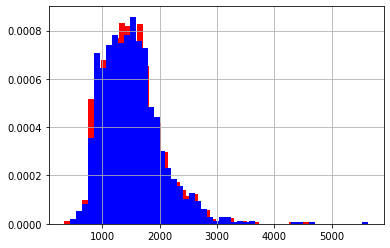

In [28]:
fig = plt.figure()
ax = fig.add_subplot(111)
data['GrLivArea'].hist(bins=50, ax=ax, density=True, color='red')
data_cleaned_cca['GrLivArea'].hist(bins=50, ax=ax, color='blue', density=True, alpha=0.4)

In [27]:
data.groupby('BsmtQual').size()

BsmtQual
Ex    121
Fa     35
Gd    618
TA    649
dtype: int64

In [ ]:
def distributionCatValues(df, df_cleaned, att):
    orig= df.groupby(att).size()
    cleaned =df_cleaned.groupby(att).size()
    result=[]

    for v,c in enumerate(orig):
      result.append([orig.index[v],c, cleaned[v]])
    return result

In [ ]:
distributionCatValues(data, data_cleaned_cca, 'BsmtQual')

[['Ex', 121, 120], ['Fa', 35, 35], ['Gd', 618, 609], ['TA', 649, 648]]

# Mean / Median imputation

Imputation is the act of replacing missing data with statistical estimates of the missing values. 

Mean / median imputation consists of replacing all occurrences of missing values (NA) within a variable by the mean (if the variable has a Gaussian distribution) or median (if the variable has a skewed distribution).


- If a variable is normally distributed, the mean, median and mode, are approximately the same. 
- If the variable is skewed, the mean is biased by the values at the far end of the distribution. Therefore, the median is a better representation of the majority of the values in the variable.



In [ ]:
data["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

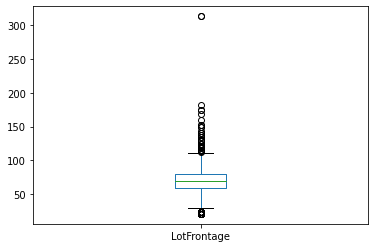

In [ ]:
data["LotFrontage"].plot(kind='box')

In [ ]:
data["LotFrontage"].isnull().sum()

259

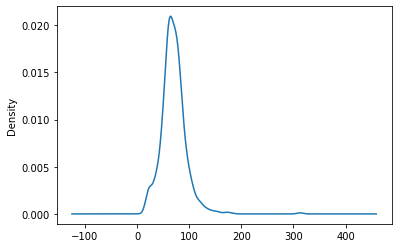

In [ ]:
data["LotFrontage"].plot(kind='kde')

In [ ]:
display(data["LotFrontage"].mean(),data["LotFrontage"].median()
)

70.04995836802665

69.0

In [ ]:
data["LotFrontage_median"] = data["LotFrontage"].fillna(data["LotFrontage"].median())

In [ ]:
data["LotFrontage_mean"] = data["LotFrontage"].fillna(data["LotFrontage"].mean())

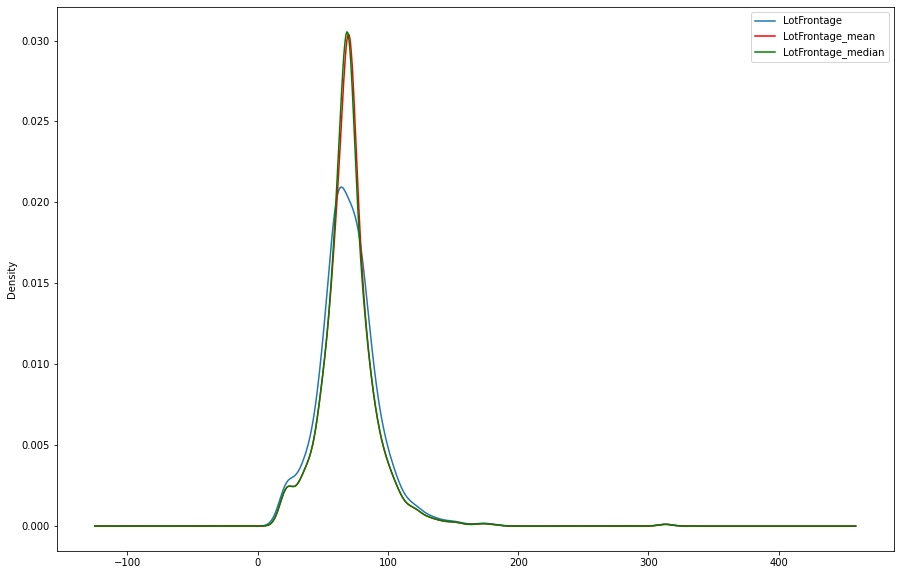

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

data["LotFrontage"].plot(kind='kde', ax=ax)
data["LotFrontage_mean"].plot(kind='kde', ax=ax, color='red')
data["LotFrontage_median"].plot(kind='kde', ax=ax, color='green')
ax.legend(loc='best')

In [ ]:
data[["LotFrontage","LotFrontage_mean","LotFrontage_median"]].describe()

,LotFrontage,LotFrontage_mean,LotFrontage_median
count,1201.000000,1460.000000,1460.000000
mean,70.049958,70.049958,69.863699
std,24.284752,22.024023,22.027677
min,21.000000,21.000000,21.000000
25%,59.000000,60.000000,60.000000
50%,69.000000,70.049958,69.000000
75%,80.000000,79.000000,79.000000
max,313.000000,313.000000,313.000000


### Using sklearn

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy='median')

In [ ]:
imputer.fit(data[["LotFrontage"]])

SimpleImputer(add_indicator=False, copy=True, fill_value=None,
              missing_values=nan, strategy='median', verbose=0)

In [ ]:
imputer.statistics_

array([69.])

In [ ]:
data["LotFrontage_median_imputer"] = imputer.transform(data[["LotFrontage"]])

In [ ]:
data["LotFrontage_median_imputer"].isnull().sum()

0

#### Using in a pipeline

In [ ]:
from sklearn.compose import ColumnTransformer

In [ ]:
data[['LotFrontage','MasVnrArea']].isnull().sum()

LotFrontage    259
MasVnrArea       8
dtype: int64

In [ ]:
preprocessor = ColumnTransformer(transformers=[
    ('mean_imputer', SimpleImputer(strategy='mean'), ["LotFrontage"]),
    ('median_imputer', SimpleImputer(strategy='median'), ["MasVnrArea"])
])#, remainder='passthrough'

In [ ]:
preprocessor.fit(data)

ColumnTransformer(n_jobs=None, remainder='drop', sparse_threshold=0.3,
                  transformer_weights=None,
                  transformers=[('mean_imputer',
                                 SimpleImputer(add_indicator=False, copy=True,
                                               fill_value=None,
                                               missing_values=nan,
                                               strategy='mean', verbose=0),
                                 ['LotFrontage']),
                                ('median_imputer',
                                 SimpleImputer(add_indicator=False, copy=True,
                                               fill_value=None,
                                               missing_values=nan,
                                               strategy='median', verbose=0),
                                 ['MasVnrArea'])],
                  verbose=False)

In [ ]:
#it returns a ndarray
preprocessor.transform(data)

array([[ 65., 196.],
       [ 80.,   0.],
       [ 68., 162.],
       ...,
       [ 66.,   0.],
       [ 68.,   0.],
       [ 75.,   0.]])

In [ ]:
newData=pd.DataFrame(preprocessor.transform(data), columns=['LotFrontage','MasVnrArea'])

In [ ]:
newData[['MasVnrArea','LotFrontage']].isnull().sum()

MasVnrArea     0
LotFrontage    0
dtype: int64

# Arbitrary value imputation

 The goal of any imputation technique is to produce a **complete dataset** that can be used to train machine learning models.

Arbitrary value imputation consists of replacing all occurrences of missing values (NA) within a variable by an arbitrary value. Typically used arbitrary values are 0, 999, -999 (or other combinations of 9s) or -1 (if the distribution is positive).

Arbitrary value imputation is also common practice in real life data collections.

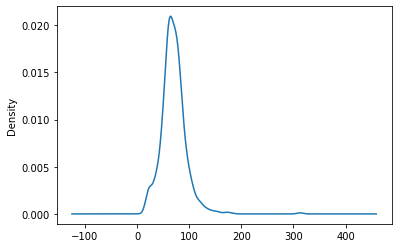

In [ ]:
  data["LotFrontage"].plot(kind='kde')

In [ ]:
 data["LotFrontage"].describe()

count    1201.000000
mean       70.049958
std        24.284752
min        21.000000
25%        59.000000
50%        69.000000
75%        80.000000
max       313.000000
Name: LotFrontage, dtype: float64

In [ ]:
 data["LotFrontage_AVI"] =  data["LotFrontage"].fillna(-1)

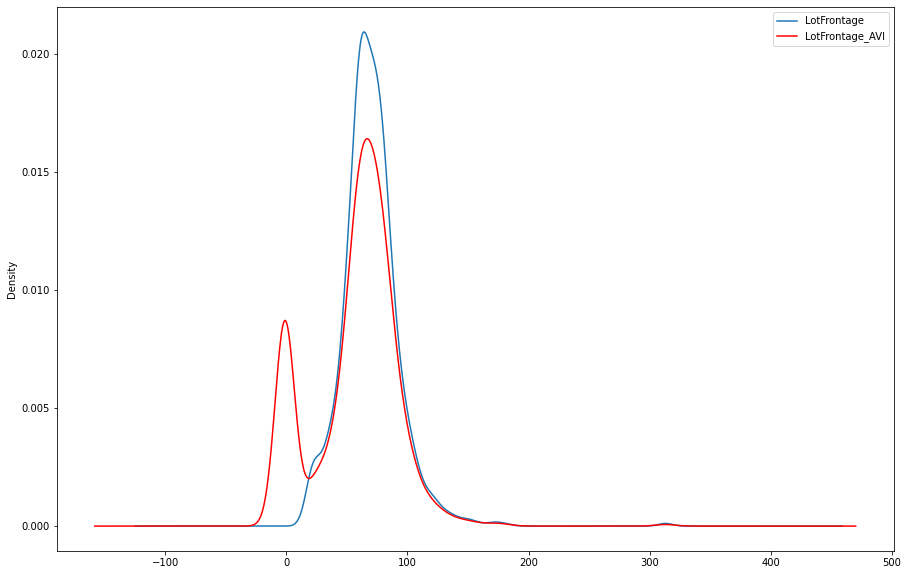

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

data["LotFrontage"].plot(kind='kde', ax=ax)
data["LotFrontage_AVI"].plot(kind='kde', ax=ax, color='red')

ax.legend(loc='best')

In [ ]:
data[["LotFrontage","LotFrontage_mean","LotFrontage_median","LotFrontage_AVI"]].describe()

,LotFrontage,LotFrontage_mean,LotFrontage_median,LotFrontage_AVI
count,1201.000000,1460.000000,1460.000000,1460.000000
mean,70.049958,70.049958,69.863699,57.445890
std,24.284752,22.024023,22.027677,34.960241
min,21.000000,21.000000,21.000000,-1.000000
25%,59.000000,60.000000,60.000000,42.000000
50%,69.000000,70.049958,69.000000,63.000000
75%,80.000000,79.000000,79.000000,79.000000
max,313.000000,313.000000,313.000000,313.000000


### Using sklearn

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy='constant', fill_value = -1)

In [ ]:
imputer.fit(data[["LotFrontage"]])

SimpleImputer(add_indicator=False, copy=True, fill_value=-1, missing_values=nan,
              strategy='constant', verbose=0)

In [ ]:
imputer.statistics_

array([-1.])

In [ ]:
data["LotFrontage_AVI_imputer"] = imputer.transform(data[["LotFrontage"]])

In [ ]:
data["LotFrontage_AVI_imputer"].isnull().sum()

0

# End of distribution imputation

We select arbitrary values at the end of the variable distributions.

- If the variable is normally distributed, we can use the mean plus or minus 3 times the standard deviation
- If the variable is skewed, we can use the IQR proximity rule (75 percentile + 3 IQR or 25 percentile - 3 IQR)

We learnt these techniques in section 3, in  the lecture on "Outliers".

- We can also select the min / max value and multiply it by a certain amount of times, like 2 or 3.


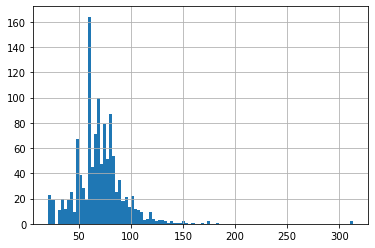

In [ ]:
data["LotFrontage"].hist(bins=100)

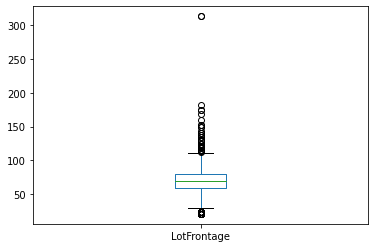

In [ ]:
data["LotFrontage"].plot(kind="box")

In [ ]:
IQR = data["LotFrontage"].quantile(0.75) - data["LotFrontage"].quantile(0.25)

In [ ]:
fill_value = data["LotFrontage"].quantile(0.75) + 1.5 * IQR
fill_value_extreme = data["LotFrontage"].quantile(0.75) + 3 * IQR
fill_value_gaussian = data["LotFrontage"].mean() + 3 * data["LotFrontage"].std() 

In [ ]:
 data["LotFrontage_end_IQR"] =  data["LotFrontage"].fillna(fill_value)
 data["LotFrontage_end_IQR_extreme"] =  data["LotFrontage"].fillna(fill_value_extreme)
 data["LotFrontage_end_IQR_gaussian"] =  data["LotFrontage"].fillna(fill_value_gaussian)

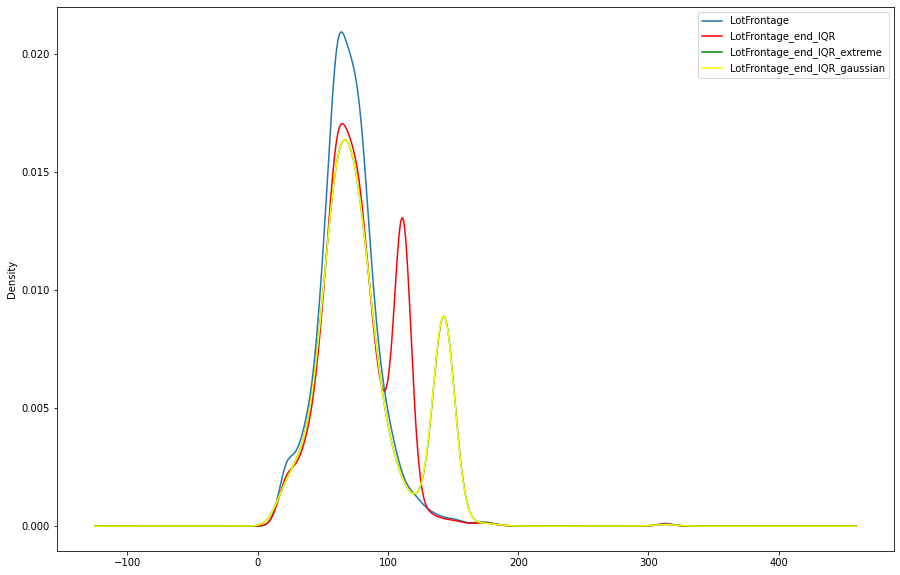

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

data["LotFrontage"].plot(kind='kde', ax=ax)
data["LotFrontage_end_IQR"].plot(kind='kde', ax=ax, color='red')
data["LotFrontage_end_IQR_extreme"].plot(kind='kde', ax=ax, color='green')
data["LotFrontage_end_IQR_gaussian"].plot(kind='kde', ax=ax, color='yellow')

ax.legend(loc='best')

# Frequent category imputation | Mode imputation

Mode imputation consists of replacing all occurrences of missing values (NA) within a variable by the mode, which in other words refers to the **most frequent value** or **most frequent category**.


In [ ]:
data['BsmtQual'].isnull().mean()

0.025342465753424658

In [ ]:
data['BsmtQual'].value_counts()

TA    649
Gd    618
Ex    121
Fa     35
Name: BsmtQual, dtype: int64

In [ ]:
data['BsmtQual'].fillna('TA')

0       Gd
1       Gd
2       Gd
3       TA
4       Gd
        ..
1455    Gd
1456    Gd
1457    TA
1458    TA
1459    TA
Name: BsmtQual, Length: 1460, dtype: object

In [ ]:
  data['BsmtQual_mode']=data['BsmtQual'].fillna('TA')

In [ ]:
data['BsmtQual_mode'].value_counts()

TA    686
Gd    618
Ex    121
Fa     35
Name: BsmtQual_mode, dtype: int64

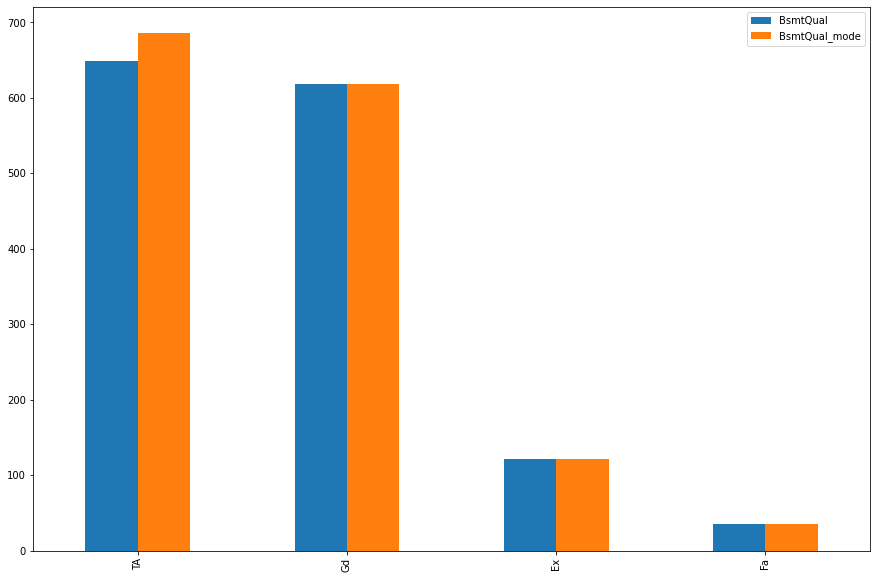

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)
#fig, ax = plt.subplots()
#ax2 = ax.twinx() # Create another axes that shares the same x-axis as ax.

#width = 0.8
#data[["BsmtQual"]].groupby(["BsmtQual"]).size().plot(kind='bar', ax=ax, position=0)
#data[["BsmtQual_mode"]].groupby(["BsmtQual_mode"]).size().plot(kind='bar', color='red', ax=ax2, width=width, position=1)

data[["BsmtQual","BsmtQual_mode"]].apply(pd.value_counts).plot(kind='bar', ax=ax)

ax.legend(loc='best')

### Using sklearn

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(strategy='most_frequent')

In [ ]:
imputer.fit(data[["LotFrontage"]])

SimpleImputer(add_indicator=False, copy=True, fill_value=None,
              missing_values=nan, strategy='most_frequent', verbose=0)

In [ ]:
imputer.statistics_

array([60.])

In [ ]:
data["LotFrontage_mode_imputer"] = imputer.transform(data[["LotFrontage"]])

In [ ]:
data["LotFrontage_mode_imputer"].isnull().sum()

0

# Arbitrary value imputation for categorical variables

All the missing observations are grouped in the newly created label 'Missing'.

In [29]:
data['BsmtQual'].value_counts()

TA    649
Gd    618
Ex    121
Fa     35
Name: BsmtQual, dtype: int64

In [30]:
data['BsmtQual_missing']=data['BsmtQual'].fillna('Missing')

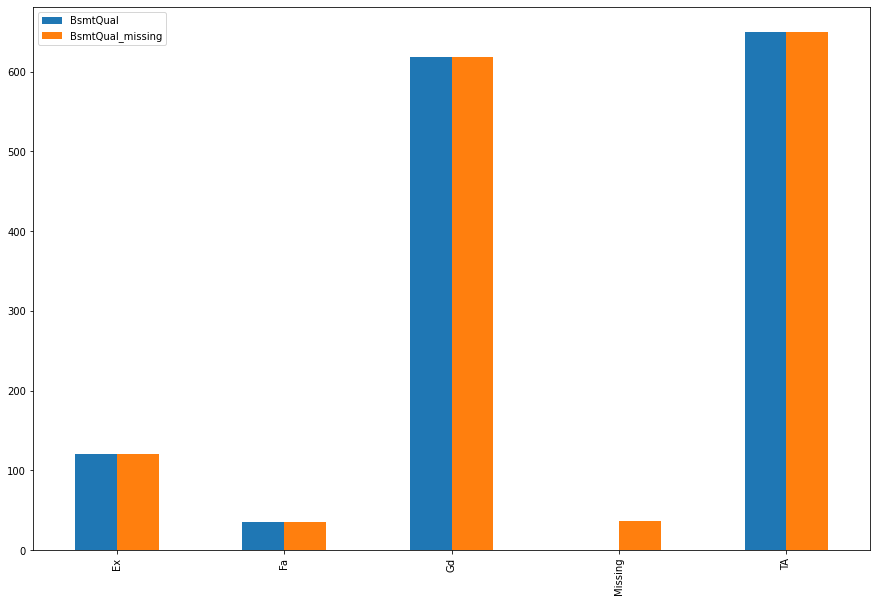

In [31]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

data[["BsmtQual","BsmtQual_missing"]].apply(pd.value_counts).plot(kind='bar', ax=ax)

ax.legend(loc='best')

### Using sklearn

In [32]:
from sklearn.impute import SimpleImputer

In [33]:
imputer = SimpleImputer(strategy='constant', fill_value = "Missing")

In [34]:
imputer.fit(data[["BsmtQual"]])

SimpleImputer(fill_value='Missing', strategy='constant')

In [35]:
imputer.statistics_

array(['Missing'], dtype=object)

In [36]:
data["BsmtQual_missing_imputer"] = imputer.transform(data[["BsmtQual"]])

In [37]:
data["BsmtQual_missing_imputer"].isnull().sum()

0

# Random sample imputation

Random sampling consist of taking a random observation from the pool of available observations of the variable, and using that randomly extracted value to fill the NA. 

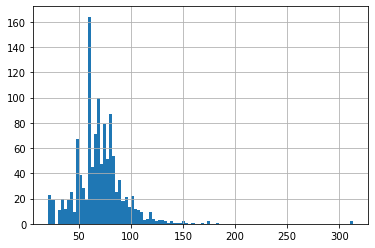

In [ ]:
data["LotFrontage"].hist(bins=100)

In [ ]:
data["LotFrontage"].isnull().sum()

259

In [ ]:
data['LotFrontage_random']= data.loc[:,'LotFrontage'].copy()

In [ ]:
data['LotFrontage'].dropna().sample(data["LotFrontage"].isnull().sum()).values

array([ 32.,  43.,  75.,  50.,  71., 118.,  78.,  85.,  95.,  80.,  60.,
        36.,  62.,  88., 111.,  50.,  84.,  70.,  84.,  92.,  60.,  85.,
        78.,  81.,  89.,  70., 104.,  37.,  55.,  64.,  57.,  63.,  65.,
        60.,  78.,  60.,  65.,  71., 100.,  80.,  68.,  75.,  57.,  60.,
        92.,  45., 105.,  70.,  60.,  35.,  65.,  63.,  43.,  70.,  60.,
        70.,  85.,  94.,  62.,  57.,  69., 100.,  24.,  70.,  86.,  71.,
        37.,  87.,  90.,  70.,  79.,  50.,  40.,  73.,  80.,  53.,  50.,
        40.,  52.,  86.,  97.,  70., 109.,  43.,  60.,  64.,  60.,  53.,
        80.,  78.,  63.,  66.,  60.,  50.,  79.,  56.,  60.,  78.,  60.,
        99.,  51., 174.,  24., 103.,  92.,  81.,  80.,  98.,  43.,  45.,
        49.,  60.,  90.,  57.,  60.,  70.,  82.,  60.,  70.,  73.,  88.,
        75., 110.,  57.,  80.,  70.,  76.,  63.,  60.,  21.,  88.,  59.,
        51.,  92.,  75.,  60.,  79.,  67.,  64.,  85.,  32.,  70., 150.,
        69., 120.,  83.,  70.,  60.,  90.,  89.,  3

In [ ]:
data['LotFrontage_random'][data['LotFrontage_random'].isnull()]=data['LotFrontage'].dropna().sample(data["LotFrontage"].isnull().sum()).values

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [ ]:
data["LotFrontage_random"].isnull().sum()

0

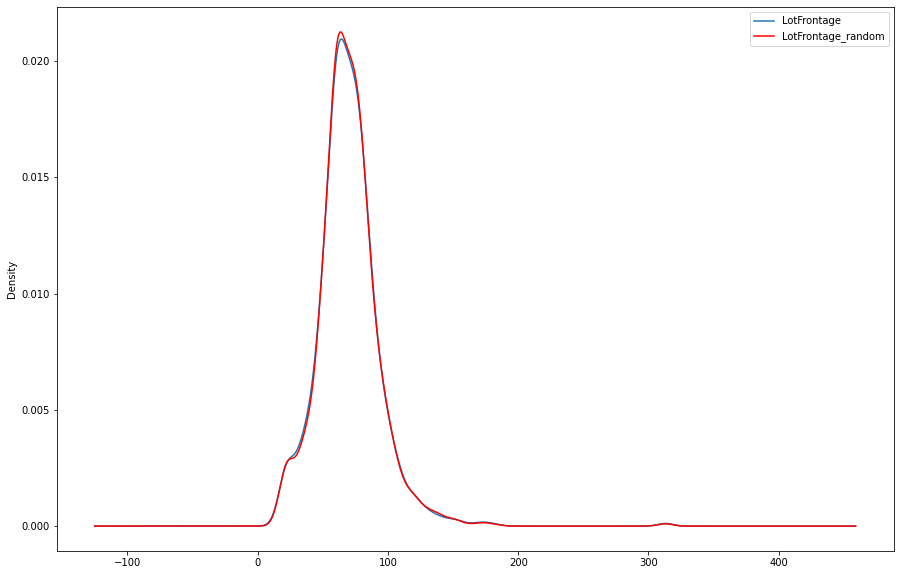

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

data["LotFrontage"].plot(kind='kde', ax=ax)
data["LotFrontage_random"].plot(kind='kde', ax=ax, color='red')

ax.legend(loc='best')

In [ ]:
data.loc[0:1,"LotFrontage"]=65

In [ ]:
data['BsmtQual'].value_counts()

TA    649
Gd    618
Ex    121
Fa     35
Name: BsmtQual, dtype: int64

In [ ]:
data['BsmtQual'].isnull().sum()

37

In [ ]:
data['BsmtQual_random']=data['BsmtQual'].copy()

In [ ]:
data['BsmtQual_random'][data['BsmtQual_random'].isnull()]=data['BsmtQual'].dropna().sample(data["BsmtQual"].isnull().sum()).values

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


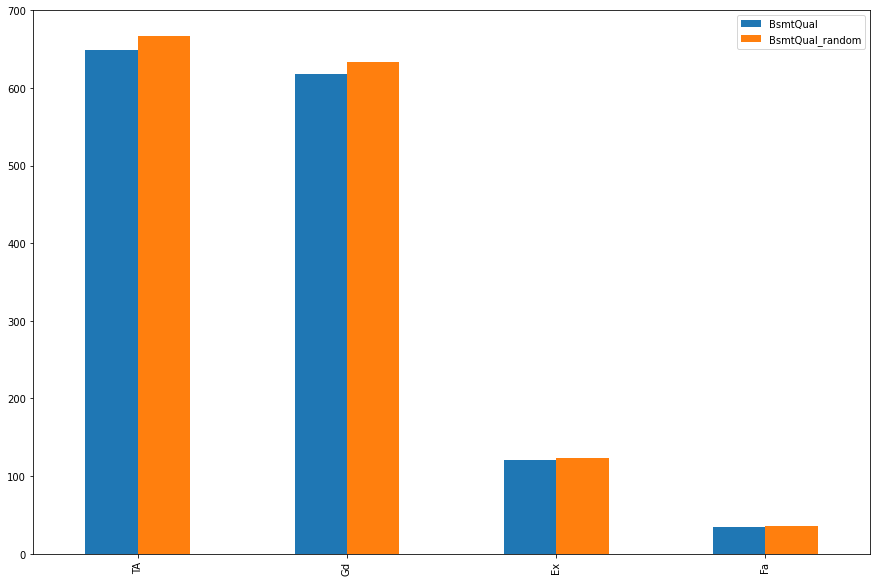

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

data[["BsmtQual","BsmtQual_random"]].apply(pd.value_counts).plot(kind='bar', ax=ax)

ax.legend(loc='best')

# Adding a variable to capture NA

If data are not missing at random, it is a good idea to replace missing observations by the mean / median / mode AND  **flag** those missing observations as well with a **Missing Indicator**. A Missing Indicator is an additional binary variable, which indicates whether the data was missing for an observation (1) or not (0).  

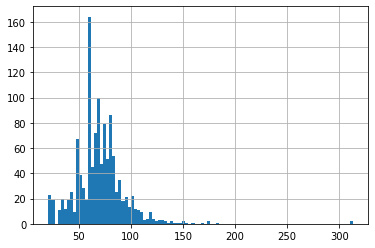

In [ ]:
data["LotFrontage"].hist(bins=100)

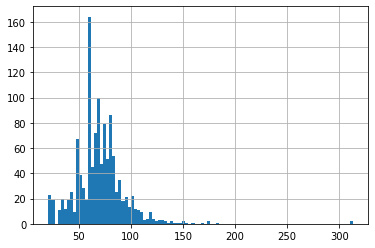

In [ ]:
data["LotFrontage"].hist(bins=100)

In [ ]:
np.where(data["LotFrontage"].isnull(), 1, 0)

array([0, 0, 0, ..., 0, 0, 0])

In [ ]:
data["LotFrontage_NAIndicator"]= np.where(data["LotFrontage"].isnull(), 1, 0)

In [ ]:
data["LotFrontage_NAIndicator"]

0       0
1       0
2       0
3       0
4       0
       ..
1455    0
1456    0
1457    0
1458    0
1459    0
Name: LotFrontage_NAIndicator, Length: 1460, dtype: int64

### Using sklearn

In [ ]:
from sklearn.impute import SimpleImputer, MissingIndicator

In [ ]:
indicator = MissingIndicator(error_on_new=True, features='missing-only')
indicator.fit(data)  

MissingIndicator(error_on_new=True, features='missing-only', missing_values=nan,
                 sparse='auto')

In [ ]:
indicator.features_

array([ 3,  6, 25, 26, 30, 31, 32, 33, 35, 42, 57, 58, 59, 60, 63, 64, 72,
       73, 74])

In [ ]:
data.columns[indicator.features_]

Index(['LotFrontage', 'Alley', 'MasVnrType', 'MasVnrArea', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Electrical', 'FireplaceQu', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PoolQC', 'Fence',
       'MiscFeature'],
      dtype='object')

In [ ]:
indicator.transform(data)

array([[False,  True, False, ...,  True,  True,  True],
       [False,  True, False, ...,  True,  True,  True],
       [False,  True, False, ...,  True,  True,  True],
       ...,
       [False,  True, False, ...,  True, False, False],
       [False,  True, False, ...,  True,  True,  True],
       [False,  True, False, ...,  True,  True,  True]])

In [ ]:
indicator_cols = [c+'_NA' for c in data.columns[indicator.features_]]

In [ ]:
data = pd.concat([
    data.reset_index(),
    pd.DataFrame(indicator.transform(data), columns = indicator_cols)], axis=1)

data.head()

,index,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotFrontage_median,LotFrontage_mean,LotFrontage_median_imputer,LotFrontage_AVI,LotFrontage_AVI_imputer,LotFrontage_end_IQR,LotFrontage_end_IQR_extreme,LotFrontage_end_IQR_gaussian,BsmtQual_mode,LotFrontage_mode_imputer,BsmtQual_missing,BsmtQual_missing_imputer,LotFrontage_random,BsmtQual_random,LotFrontage_NAIndicator,LotFrontage_NA,Alley_NA,MasVnrType_NA,MasVnrArea_NA,BsmtQual_NA,BsmtCond_NA,BsmtExposure_NA,BsmtFinType1_NA,BsmtFinType2_NA,Electrical_NA,FireplaceQu_NA,GarageType_NA,GarageYrBlt_NA,GarageFinish_NA,GarageQual_NA,GarageCond_NA,PoolQC_NA,Fence_NA,MiscFeature_NA
0,0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,65.0,65.0,65.0,65.0,65.0,65.0,65.0,65.0,Gd,65.0,Gd,Gd,65.0,Gd,0,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,True,True
1,1,2,20,RL,65.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,80.0,80.0,80.0,80.0,80.0,80.0,80.0,80.0,Gd,80.0,Gd,Gd,80.0,Gd,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
2,2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,68.0,68.0,68.0,68.0,68.0,68.0,68.0,68.0,Gd,68.0,Gd,Gd,68.0,Gd,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
3,3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,60.0,60.0,60.0,60.0,60.0,60.0,60.0,60.0,TA,60.0,TA,TA,60.0,TA,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True
4,4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,84.0,84.0,84.0,84.0,84.0,84.0,84.0,84.0,Gd,84.0,Gd,Gd,84.0,Gd,0,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,True


# Using the pipeline for categorical and numerical features

In [ ]:
cols_to_use = [
    'BsmtQual', 'FireplaceQu', 'LotFrontage', 'MasVnrArea', 'GarageYrBlt',
    'SalePrice'
]

data = pd.read_csv('houseprice.csv', usecols=cols_to_use)
data.head()

features_numeric = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
features_categoric = ['BsmtQual', 'FireplaceQu']


preprocessor = ColumnTransformer(transformers=[
    ('imputer_numeric', SimpleImputer(strategy='mean'), features_numeric),
    ('imputer_categoric', SimpleImputer(strategy='constant', fill_value='Missing'), features_categoric)])

In [ ]:
preprocessor.fit(data)

ColumnTransformer(n_jobs=None, remainder='drop', sparse_threshold=0.3,
                  transformer_weights=None,
                  transformers=[('imputer_numeric',
                                 SimpleImputer(add_indicator=False, copy=True,
                                               fill_value=None,
                                               missing_values=nan,
                                               strategy='mean', verbose=0),
                                 ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']),
                                ('imputer_categoric',
                                 SimpleImputer(add_indicator=False, copy=True,
                                               fill_value='Missing',
                                               missing_values=nan,
                                               strategy='constant', verbose=0),
                                 ['BsmtQual', 'FireplaceQu'])],
                  verbose=False)

In [ ]:
preprocessor.transform(data)

array([[65.0, 196.0, 2003.0, 'Gd', 'Missing'],
       [80.0, 0.0, 1976.0, 'Gd', 'TA'],
       [68.0, 162.0, 2001.0, 'Gd', 'TA'],
       ...,
       [66.0, 0.0, 1941.0, 'TA', 'Gd'],
       [68.0, 0.0, 1950.0, 'TA', 'Missing'],
       [75.0, 0.0, 1965.0, 'TA', 'Missing']], dtype=object)

In [ ]:
pd.DataFrame(preprocessor.transform(data),
             columns=features_numeric+features_categoric).head()

# KNN imputation

The missing values are estimated as the average value from the closest K neighbours.


In [ ]:
from sklearn.impute import KNNImputer

In [ ]:
data = pd.read_csv('houseprice.csv')

In [ ]:
data.dtypes[data.dtypes=='object']

MSZoning         object
Street           object
Alley            object
LotShape         object
LandContour      object
Utilities        object
LotConfig        object
LandSlope        object
Neighborhood     object
Condition1       object
Condition2       object
BldgType         object
HouseStyle       object
RoofStyle        object
RoofMatl         object
Exterior1st      object
Exterior2nd      object
MasVnrType       object
ExterQual        object
ExterCond        object
Foundation       object
BsmtQual         object
BsmtCond         object
BsmtExposure     object
BsmtFinType1     object
BsmtFinType2     object
Heating          object
HeatingQC        object
CentralAir       object
Electrical       object
KitchenQual      object
Functional       object
FireplaceQu      object
GarageType       object
GarageFinish     object
GarageQual       object
GarageCond       object
PavedDrive       object
PoolQC           object
Fence            object
MiscFeature      object
SaleType        

In [ ]:
data[data.dtypes[data.dtypes!='object'].index].isnull().sum()

Id                 0
MSSubClass         0
LotFrontage      259
LotArea            0
OverallQual        0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
MasVnrArea         8
BsmtFinSF1         0
BsmtFinSF2         0
BsmtUnfSF          0
TotalBsmtSF        0
1stFlrSF           0
2ndFlrSF           0
LowQualFinSF       0
GrLivArea          0
BsmtFullBath       0
BsmtHalfBath       0
FullBath           0
HalfBath           0
BedroomAbvGr       0
KitchenAbvGr       0
TotRmsAbvGrd       0
Fireplaces         0
GarageYrBlt       81
GarageCars         0
GarageArea         0
WoodDeckSF         0
OpenPorchSF        0
EnclosedPorch      0
3SsnPorch          0
ScreenPorch        0
PoolArea           0
MiscVal            0
MoSold             0
YrSold             0
SalePrice          0
dtype: int64

In [ ]:
imputer = KNNImputer(
    n_neighbors=5, # the number of neighbours K
    weights='distance', # the weighting factor
    metric='nan_euclidean', # the metric to find the neighbours
    add_indicator=False, # whether to add a missing indicator
)

In [ ]:
imputer.fit(data[data.dtypes[data.dtypes!='object'].index])

KNNImputer(add_indicator=False, copy=True, metric='nan_euclidean',
           missing_values=nan, n_neighbors=5, weights='distance')

In [ ]:
dataNoMissing=imputer.transform(data[data.dtypes[data.dtypes!='object'].index])

In [ ]:
dataNoMissing

array([[1.00000e+00, 6.00000e+01, 6.50000e+01, ..., 2.00000e+00,
        2.00800e+03, 2.08500e+05],
       [2.00000e+00, 2.00000e+01, 8.00000e+01, ..., 5.00000e+00,
        2.00700e+03, 1.81500e+05],
       [3.00000e+00, 6.00000e+01, 6.80000e+01, ..., 9.00000e+00,
        2.00800e+03, 2.23500e+05],
       ...,
       [1.45800e+03, 7.00000e+01, 6.60000e+01, ..., 5.00000e+00,
        2.01000e+03, 2.66500e+05],
       [1.45900e+03, 2.00000e+01, 6.80000e+01, ..., 4.00000e+00,
        2.01000e+03, 1.42125e+05],
       [1.46000e+03, 2.00000e+01, 7.50000e+01, ..., 6.00000e+00,
        2.00800e+03, 1.47500e+05]])

In [ ]:
dataNoMissing = pd.DataFrame(dataNoMissing, columns=data.dtypes[data.dtypes!='object'].index)

In [ ]:
dataNoMissing.isnull().sum()

Id               0
MSSubClass       0
LotFrontage      0
LotArea          0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
MasVnrArea       0
BsmtFinSF1       0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
TotRmsAbvGrd     0
Fireplaces       0
GarageYrBlt      0
GarageCars       0
GarageArea       0
WoodDeckSF       0
OpenPorchSF      0
EnclosedPorch    0
3SsnPorch        0
ScreenPorch      0
PoolArea         0
MiscVal          0
MoSold           0
YrSold           0
SalePrice        0
dtype: int64

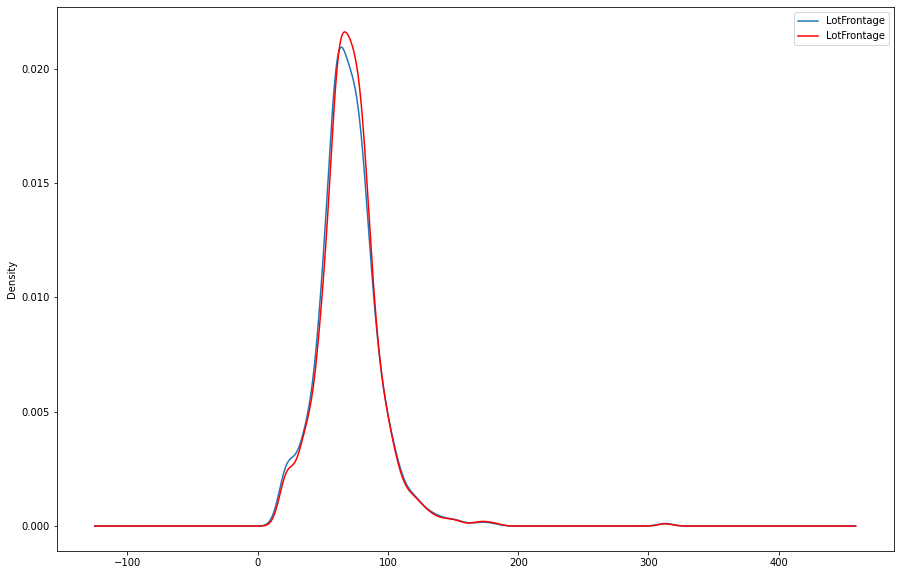

In [ ]:
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111)

data["LotFrontage"].plot(kind='kde', ax=ax)
dataNoMissing["LotFrontage"].plot(kind='kde', ax=ax, color='red')

ax.legend(loc='best')